In [ ]:
!pip -q install rasterio

import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import matplotlib.pyplot as plt

import rasterio
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/Satellite_ML_Research_Project/Dataset/allBands" "/content"

ValueError: mount failed

In [ ]:
dataset_path = "/content/allBands"
print("Dataset path exists:", os.path.exists(dataset_path))

Dataset path exists: True


In [ ]:
class EuroSATAllBandsMultiIndex(Dataset):
    def __init__(self, root_dir, img_size=224):
        self.root_dir = root_dir
        self.img_size = img_size

        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for f in os.listdir(cls_path):
                if f.lower().endswith(".tif"):
                    self.samples.append((os.path.join(cls_path, f), self.class_to_idx[cls]))

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        with rasterio.open(path) as src:
            img = src.read()  # (bands, H, W)

        img = img.astype(np.float32)

        # EuroSAT allBands typical order:
        # B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
        # indices (0-based):
        # B02=1, B03=2, B04=3, B08=7, B11=11

        B02 = img[1]   # Blue
        B03 = img[2]   # Green
        B04 = img[3]   # Red
        B08 = img[7]   # NIR
        B11 = img[11]  # SWIR

        def norm_band(b):
            b = b - b.min()
            if b.max() > 0:
                b = b / b.max()
            return b

        blue  = norm_band(B02)
        green = norm_band(B03)
        red   = norm_band(B04)
        nir   = norm_band(B08)
        swir  = norm_band(B11)

        eps = 1e-6

        ndvi = (nir - red) / (nir + red + eps)
        ndwi = (green - nir) / (green + nir + eps)
        ndbi = (swir - nir) / (swir + nir + eps)

        ndvi_value = float(np.mean(ndvi))
        ndwi_value = float(np.mean(ndwi))
        ndbi_value = float(np.mean(ndbi))

        rgb = np.stack([red, green, blue], axis=-1)
        rgb = (rgb * 255).astype(np.uint8)
        rgb_tensor = self.transform(rgb)

        return (
            rgb_tensor,
            torch.tensor(label, dtype=torch.long),
            torch.tensor(ndvi_value, dtype=torch.float32),
            torch.tensor(ndwi_value, dtype=torch.float32),
            torch.tensor(ndbi_value, dtype=torch.float32),
        )
full_dataset = EuroSATAllBandsMultiIndex(dataset_path, img_size=224)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))


Total images: 27611
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 19327 Val: 4141 Test: 4143


In [ ]:
class MultiTaskResNet4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.head_cls = nn.Linear(in_features, num_classes)
        self.head_ndvi = nn.Linear(in_features, 1)
        self.head_ndwi = nn.Linear(in_features, 1)
        self.head_ndbi = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.backbone(x)
        logits = self.head_cls(feat)
        ndvi = self.head_ndvi(feat).squeeze(1)
        ndwi = self.head_ndwi(feat).squeeze(1)
        ndbi = self.head_ndbi(feat).squeeze(1)
        return logits, ndvi, ndwi, ndbi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes)

model = MultiTaskResNet4(num_classes=num_classes).to(device)

loss_cls = nn.CrossEntropyLoss()
loss_reg = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Device:", device)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


Device: cuda


In [ ]:
def eval_model(loader):
    model.eval()

    total = 0
    correct = 0

    ndvi_err = []
    ndwi_err = []
    ndbi_err = []

    with torch.no_grad():
        for imgs, labels, ndvi, ndwi, ndbi in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            ndvi = ndvi.to(device)
            ndwi = ndwi.to(device)
            ndbi = ndbi.to(device)

            logits, ndvi_pred, ndwi_pred, ndbi_pred = model(imgs)
            preds = torch.argmax(logits, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            ndvi_err.extend((ndvi_pred - ndvi).abs().cpu().numpy())
            ndwi_err.extend((ndwi_pred - ndwi).abs().cpu().numpy())
            ndbi_err.extend((ndbi_pred - ndbi).abs().cpu().numpy())

    acc = correct / total
    ndvi_mae = float(np.mean(ndvi_err))
    ndwi_mae = float(np.mean(ndwi_err))
    ndbi_mae = float(np.mean(ndbi_err))

    return acc, ndvi_mae, ndwi_mae, ndbi_mae


In [ ]:
epochs = 8

w_ndvi = 1.0
w_ndwi = 1.0
w_ndbi = 1.0

train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    t0 = time.time()
    running_loss = 0.0

    for imgs, labels, ndvi, ndwi, ndbi in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        ndvi = ndvi.to(device)
        ndwi = ndwi.to(device)
        ndbi = ndbi.to(device)

        optimizer.zero_grad()

        logits, ndvi_pred, ndwi_pred, ndbi_pred = model(imgs)

        L_cls = loss_cls(logits, labels)
        L_ndvi = loss_reg(ndvi_pred, ndvi)
        L_ndwi = loss_reg(ndwi_pred, ndwi)
        L_ndbi = loss_reg(ndbi_pred, ndbi)

        loss = L_cls + w_ndvi*L_ndvi + w_ndwi*L_ndwi + w_ndbi*L_ndbi
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_acc, train_ndvi_mae, train_ndwi_mae, train_ndbi_mae = eval_model(train_loader)
    val_acc, val_ndvi_mae, val_ndwi_mae, val_ndbi_mae = eval_model(val_loader)

    train_history.append([train_acc, train_ndvi_mae, train_ndwi_mae, train_ndbi_mae])
    val_history.append([val_acc, val_ndvi_mae, val_ndwi_mae, val_ndbi_mae])

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | "
        f"Val MAE NDVI: {val_ndvi_mae:.4f} | Val MAE NDWI: {val_ndwi_mae:.4f} | Val MAE NDBI: {val_ndbi_mae:.4f} | "
        f"Time: {time.time()-t0:.1f}s"
    )


Epoch 1/8 | Loss: 0.4419 | Train Acc: 98.24% | Val Acc: 96.21% | Val MAE NDVI: 0.1201 | Val MAE NDWI: 0.1184 | Val MAE NDBI: 0.1473 | Time: 230.4s
Epoch 2/8 | Loss: 0.1682 | Train Acc: 99.49% | Val Acc: 96.91% | Val MAE NDVI: 0.1058 | Val MAE NDWI: 0.1039 | Val MAE NDBI: 0.1365 | Time: 201.7s
Epoch 3/8 | Loss: 0.1129 | Train Acc: 99.50% | Val Acc: 96.50% | Val MAE NDVI: 0.1070 | Val MAE NDWI: 0.1099 | Val MAE NDBI: 0.1421 | Time: 202.0s
Epoch 4/8 | Loss: 0.0888 | Train Acc: 99.86% | Val Acc: 97.30% | Val MAE NDVI: 0.1067 | Val MAE NDWI: 0.0984 | Val MAE NDBI: 0.1333 | Time: 201.5s
Epoch 5/8 | Loss: 0.0753 | Train Acc: 99.78% | Val Acc: 97.17% | Val MAE NDVI: 0.1029 | Val MAE NDWI: 0.1033 | Val MAE NDBI: 0.1273 | Time: 213.9s
Epoch 6/8 | Loss: 0.0707 | Train Acc: 99.63% | Val Acc: 96.76% | Val MAE NDVI: 0.0983 | Val MAE NDWI: 0.1021 | Val MAE NDBI: 0.1275 | Time: 202.2s
Epoch 7/8 | Loss: 0.0602 | Train Acc: 99.78% | Val Acc: 96.62% | Val MAE NDVI: 0.0954 | Val MAE NDWI: 0.0956 | Val MAE

In [ ]:
test_acc, test_ndvi_mae, test_ndwi_mae, test_ndbi_mae = eval_model(test_loader)

print("\nFINAL TEST RESULTS")
print("Test Accuracy:", test_acc*100)
print("NDVI MAE:", test_ndvi_mae)
print("NDWI MAE:", test_ndwi_mae)
print("NDBI MAE:", test_ndbi_mae)



FINAL TEST RESULTS
Test Accuracy: 96.98286265990828
NDVI MAE: 0.09989893436431885
NDWI MAE: 0.09467989951372147
NDBI MAE: 0.1252068132162094


In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels, ndvi, ndwi, ndbi in test_loader:
        imgs = imgs.to(device)
        logits, _, _, _ = model(imgs)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)



Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.98      0.96       437
              Forest       0.99      0.99      0.99       427
HerbaceousVegetation       0.94      0.98      0.96       469
             Highway       0.98      0.97      0.97       394
          Industrial       0.97      0.98      0.97       376
             Pasture       0.98      0.94      0.96       291
       PermanentCrop       0.97      0.92      0.94       373
         Residential       1.00      0.97      0.98       427
               River       0.97      0.96      0.97       396
             SeaLake       0.97      0.98      0.98       553

            accuracy                           0.97      4143
           macro avg       0.97      0.97      0.97      4143
        weighted avg       0.97      0.97      0.97      4143


Confusion Matrix:
 [[429   0   0   2   0   1   3   0   1   1]
 [  0 424   2   0   0   0   0   0   0   1]

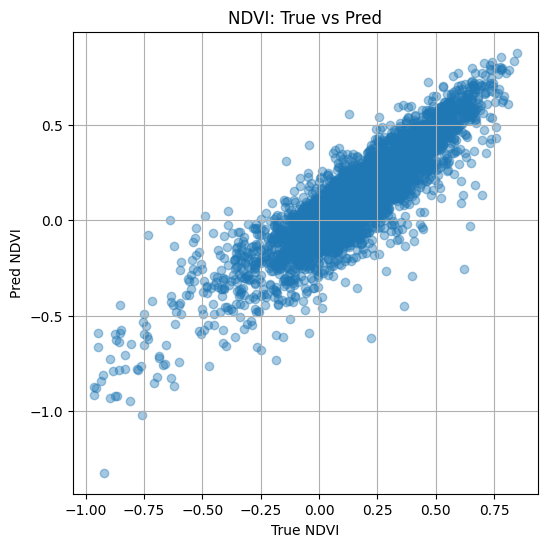

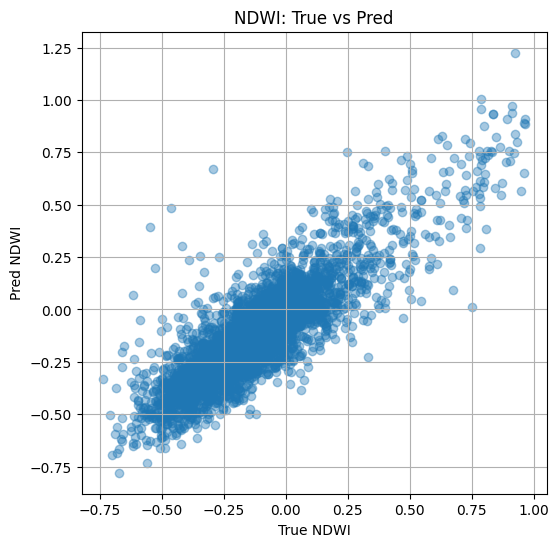

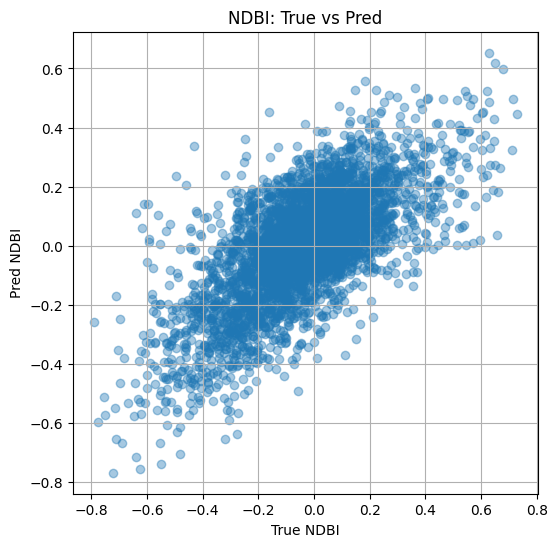

In [ ]:
true_ndvi, pred_ndvi = [], []
true_ndwi, pred_ndwi = [], []
true_ndbi, pred_ndbi = [], []

model.eval()
with torch.no_grad():
    for imgs, labels, ndvi, ndwi, ndbi in test_loader:
        imgs = imgs.to(device)
        logits, ndvi_p, ndwi_p, ndbi_p = model(imgs)

        true_ndvi.extend(ndvi.numpy()); pred_ndvi.extend(ndvi_p.cpu().numpy())
        true_ndwi.extend(ndwi.numpy()); pred_ndwi.extend(ndwi_p.cpu().numpy())
        true_ndbi.extend(ndbi.numpy()); pred_ndbi.extend(ndbi_p.cpu().numpy())

plt.figure(figsize=(6,6))
plt.scatter(true_ndvi, pred_ndvi, alpha=0.4)
plt.xlabel("True NDVI"); plt.ylabel("Pred NDVI")
plt.title("NDVI: True vs Pred")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(true_ndwi, pred_ndwi, alpha=0.4)
plt.xlabel("True NDWI"); plt.ylabel("Pred NDWI")
plt.title("NDWI: True vs Pred")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(true_ndbi, pred_ndbi, alpha=0.4)
plt.xlabel("True NDBI"); plt.ylabel("Pred NDBI")
plt.title("NDBI: True vs Pred")
plt.grid(True)
plt.show()


In [ ]:
torch.save(model, "model.pth")
!cp multitask_land_ndvi_ndwi_ndbi.pth "/content/drive/MyDrive/Satellite_ML_Research_Project/Models/"
print("Saved to Drive ✅")


NameError: name 'torch' is not defined